In [51]:
import numpy as np
import torch
import matplotlib.pyplot as plt

from tqdm.notebook import tqdm
from torchvision import datasets
from sklearn.model_selection import train_test_split


In [35]:
class Conv2d:
    def __init__(self, _in: int, _out: int, kernel_size: int, stride: int=1, padding: int=0, bias: bool=True):

        self.n_input = _in
        self.n_output = _out
        self.kernel_size = kernel_size
        self.stride = stride
        self.padding = padding
        self.bias = bias

        fan_in = self.n_input * self.kernel_size**2
        self.w = np.random.randn(self.n_output, self.n_input, self.kernel_size, self.kernel_size) * np.sqrt(2.0 / fan_in)
        if self.bias:
            self.b = np.zeros((self.n_output))

        else: self.b = None

        self.dw = None
        self.db = None
        self.dx = None

    def conv(self, left_arr, right_arr, pad_override=None, stride_override=None, mode="forward"):
        pad = self.padding if pad_override is None else pad_override
        stride = self.stride if stride_override is None else stride_override

        if mode == "forward":
            return self._conv_forward(left_arr, right_arr, pad, stride)
        elif mode == "dw":
            return self._conv_grad_weight(left_arr, right_arr, pad, stride)
        elif mode == "dx":
            return self._conv_grad_input(left_arr, right_arr, pad, stride)
        else:
            raise ValueError(f"Unknown mode: {mode}")

    def _conv_forward(self, x, w, pad, stride):
        N, C_in, H, W = x.shape
        C_out, _, K, _ = w.shape

        H_out = (H + 2 * pad - K) // stride + 1
        W_out = (W + 2 * pad - K) // stride + 1

        if pad > 0:
            x_pad = np.pad(x, ((0,0), (0,0), (pad, pad), (pad, pad)), mode="constant")
        else:
            x_pad = x

        out = np.zeros((N, C_out, H_out, W_out))

        for i in range(H_out):
            for j in range(W_out):
                h_idx = slice(i * stride, i * stride + K)
                w_idx = slice(j * stride, j * stride + K)
                region = x_pad[:, np.newaxis, :, h_idx, w_idx]
                out[..., i, j] = np.sum(region * w, axis=(2, 3, 4))

        return out

    def _conv_grad_weight(self, x, dout, pad, stride):
        N, C_in, H, W = x.shape
        _, C_out, _, _ = dout.shape
        K = self.kernel_size

        H_out = H + 2*pad - K + 1
        W_out = W + 2*pad - K + 1

        dout_dil = np.zeros((N, C_out, H_out, W_out), dtype=dout.dtype)
        dout_dil[..., ::self.stride, ::self.stride] = dout
        dout = dout_dil[:, :, np.newaxis, :, :]

        dw = np.zeros((C_out, C_in, K, K))

        if pad > 0:
            x_pad = np.pad(x, ((0,0), (0,0), (pad, pad), (pad, pad)), mode="constant")
        else:
            x_pad = x

        for i in range(K):
            for j in range(K):
                h_idx = slice(i, i + H_out)
                w_idx = slice(j, j + W_out)
                region = x_pad[:, np.newaxis, :, h_idx, w_idx]
                dw[..., i, j] = np.sum(region * dout, axis=(0, 3, 4))

        return dw

    def _conv_grad_input(self, dout, w, pad, stride):
        N, _, H_in, W_in = self.x.shape
        C_in, C_out, K, _ = w.shape

        if stride < self.stride:
            H_out = H_in + K - 2*pad - 1
            W_out = W_in + K - 2*pad - 1
            dout_dil = np.zeros((N, C_out, H_out, W_out), dtype=dout.dtype)
            dout_dil[..., ::self.stride, ::self.stride] = dout
            dout = dout_dil

        N, C_out, H_out, W_out = dout.shape


        if pad > 0:
            dout_pad = np.pad(dout, ((0, 0), (0,0), (pad, pad), (pad, pad)), mode="constant")

        elif pad < 0:
            dout_pad = dout[..., -pad:pad, -pad:pad]
        else:
            dout_pad = dout

        dx = np.zeros((N, C_in, H_in, W_in))

        for i in range(H_in):
            for j in range(W_in):
                h_idx = slice(i, i + K)
                w_idx = slice(j, j + K)
                region = dout_pad[:, np.newaxis, :, h_idx, w_idx]
                dx[..., i, j] = np.sum(region * w, axis=(2, 3, 4))

        return dx

    def forward(self, x):
        self.x = x
        out = self.conv(self.x, self.w, mode='forward')

        if self.bias:
            out += self.b[:, np.newaxis, np.newaxis]
        return out

    def backward(self, dout):
        N, C_in, H, W = self.x.shape

        if self.bias:
            self.db = np.sum(dout, axis=(0, 2, 3), keepdims=False)

        self.dw = self.conv(self.x, dout, stride_override=1, mode="dw")

        w_rot = self.w[:, :, ::-1, ::-1]
        w_dx = w_rot.transpose(1, 0, 2, 3)
        pad_dx = self.kernel_size - 1 - self.padding

        self.dx = self.conv(dout, w_dx, pad_override=pad_dx, stride_override=1, mode='dx')

        return self.dx    

In [36]:
class SGD:
    def __init__(self, lr: float = 1e-3, beta1: float = 0.9, weight_decay: float = 0):
        self.lr = lr
        self.beta1 = beta1
        self.weight_decay = weight_decay

        self.m = []

    def step(self, params: list[np.ndarray], grads: list[np.ndarray]) -> list[np.ndarray]:
        for i, (param, grad) in enumerate(zip(params, grads)):
            if len(self.m) != len(params):
                self.m.append(np.zeros_like(param))

            m = self.m[i]
            m = self.beta1 * m + (1 - self.beta1) * m

            param_new = (param - self.lr * m - self.lr * self.weight_decay * param)
            self.m[i] = m
            params[i] = param_new

        return params

In [37]:
class RMSprop:
    def __init__(self, lr: float = 1e-3, beta2: float = 0.999, eps: float = 1e-8, weight_decay: float = 0):
        self.lr = lr
        self.beta2 = beta2
        self.eps = eps
        self.weight_decay = weight_decay

        self.v = []

    def step(self, params: list[np.ndarray], grads: list[np.ndarray]) -> list[np.ndarray]:
        for i, (param, grad) in enumerate(zip(params, grads)):

            if len(self.v) != len(params):
                self.v.append(np.zeros_like(param))

            v = self.v[i]
            v = self.beta2 * v + (1 - self.beta2) * np.square(grad)

            lr_step = self.lr / (np.sqrt(v) + self.eps)
            new_param = param - lr_step * grad - self.lr * self.weigth_decay * param

            self.v[i] = v
            params[i] = new_param

        return params

In [38]:
class AdamW:
    def __init__(self, lr: float = 1e-3, beta1: float = 0.9, beta2: float = 0.999, eps: float = 1e-8, weight_decay: float = 0):
        self.lr = lr
        self.beta1 = beta1
        self.beta2 = beta2
        self.eps = eps
        self.weight_decay = weight_decay
        self.t = 0

        self.m = []
        self.v = []

    def step(self, params: list[np.ndarray], grads: list[np.ndarray]) -> list[np.ndarray]:
        self.t += 1

        for i, (param, grad) in enumerate(zip(params, grads)):
            if len(self.v) != len(params):
                self.m.append(np.zeros_like(param))
                self.v.append(np.zeros_like(param))

            m = self.beta1 * self.m[i] + (1 - self.beta1) * grad
            v = self.beta2 * self.v[i] + (1 - self.beta2) * np.square(grad)

            m_hat = m / (1 - self.beta1** self.t)
            v_hat = v / (1 - self.beta2** self.t)

            adam_step = m_hat/(np.sqrt(v_hat) + self.eps)
            param_new = param - self.lr * adam_step - self.lr * self.weight_decay * param

            self.v[i] = v
            self.m[i] = m
            params[i] = param_new

        return params

In [39]:
def load_mnist_simple(
    train: bool = True,
    root: str = "./data",
) -> tuple[np.ndarray, np.ndarray]:
    num_class = 10
    dataset = datasets.MNIST(
        root=root,
        train=train,
        download=True
    )

    images = np.stack([img for img, _ in dataset])
    images = images.astype(np.uint8)

    labels = np.array([label for _, label in dataset])
    one_hot = np.eye(num_class)[labels]

    return images, one_hot

def label_to_onehot(label: int, num_class: int = 10) -> np.ndarray:
    one_hot = np.zeros(num_class)
    one_hot[label] = 1
    return one_hot


def onehot_to_label(one_hot: np.ndarray) -> np.ndarray:
    return np.argmax(one_hot)

def to_label(pred_bs: np.ndarray) -> np.ndarray:
    return np.argmax(pred_bs, axis=-1)


In [8]:
class CrossEntropyLoss:

    def forward(self, pred: np.ndarray, target: np.ndarray) -> float:
        self.batch_size = pred.shape[0]
        self.target = target

        logits_max = pred.max(axis=1, keepdims=True)
        exp_pred = np.exp(pred - logits_max)

        self.softmax = exp_pred / exp_pred.sum(axis=1, keepdims=True)

        log_sum_exp = np.log(exp_pred.sum(axis=1, keepdims=True))
        loss = (-np.sum(target * pred, axis=1, keepdims=True) + logits_max + log_sum_exp)

        return loss.mean()

    def backward(self) -> np.ndarray:
        return (self.softmax - self.target) / self.batch_size

    def __call__(self, pred: np.ndarray, target: np.ndarray) -> float:
        return self.forward(pred, target)

In [40]:
class Dropout:
    def __init__(self, p: float=0.5, train=True):
        self.p = p
        self.training = train
        self.scale = 1/ (1 - self.p)

    def forward(self, x: np.ndarray) -> np.ndarray:
        if not self.training:
            return x

        self.mask = (np.random.rand(*x.shape) > self.p)
        return x * self.mask * self.scale

    def backward(self, grad_output: np.ndarray) -> np.ndarray:
        return grad_output * self.mask * self.scale

    def __call__(self, x: np.ndarray) -> np.ndarray:
        return self.forward(x)

In [41]:
def relu(x: np.ndarray) -> np.ndarray:
    return np.maximum(0, x)

def drelu(act: np.ndarray, grad: np.ndarray) -> np.ndarray:
    return grad * np.where(act > 0, 1, 0)

def softmax(x : np.ndarray) -> np.ndarray:
    max_x = np.max(x, axis=1, keepdims=True)
    exp_x = np.exp(x - max_x)
    return exp_x / np.sum(exp_x, axis=1, keepdims=True)

In [45]:
def normalize(sample: np.ndarray) -> np.ndarray:
    s_min = np.min(sample, axis=(2, 3, 4), keepdims=True)
    s_max = np.max(sample, axis=(2, 3, 4), keepdims=True)
    return (sample - s_min) / (s_max - s_min) *2 - 1

def initialization_params(size: tuple[int, int], mode: str="normal", seed: int=None, empas: str="in") -> np.ndarray:
    rng = np.random.default_rng(seed)
    n_in, n_out = size
    gain = np.sqrt(2)

    if mode == 'normal':
        return rng.standard_normal(size=size)

    elif mode == "xavier_normal":
        std = gain * np.sqrt(2.0 / (n_in + n_out))
        return rng.normal(0, std, size=size)

    elif mode == "xavier_uniform":
        bound = gain * np.sqrt(6.0 / (n_in + n_out))
        return rng.uniform(-bound, bound, size=size)

    elif mode == "kaiming_normal":
        std = gain * np.sqrt(1.0 / (n_in if empas=="in" else n_out))
        return rng.normal(0, std, size=size)

    elif mode == "kaiming_uniform":
        bound = gain * np.sqrt(3.0 / (n_in if empas=="in" else n_out))
        return rng.uniform(-bound, bound, size=size)
    else:
        raise ValueError("Данный тип инициализации весов еще не был введен")

def create_layers(n_input: int, n_output: int, mode: str="normal", seed: int=None, n_hidden: int=128) -> tuple[np.ndarray, ...]:
    W1 = initialization_params(size=(n_input, n_hidden), mode=mode, seed=seed)
    b1 = initialization_params(size=(1, n_hidden), mode=mode, seed=seed)

    W2 = initialization_params(size=(n_hidden, n_output), mode=mode, seed=seed)
    b2 = initialization_params(size=(1, n_output), mode=mode, seed=seed)
    return (W1, b1, W2, b2)

def data_loader(data: tuple[np.ndarray, np.ndarray], n_input: int, n_output: int, batch_size: int, epoch: int, shuffle: bool = False, seed: int = None):
    imgs, targets = data
    data_size = imgs.shape[0]
    num_batches = data_size // batch_size
    total = num_batches * batch_size
    in_channels = 1
    H_in = 28
    W_in = 28

    if shuffle:
        rng = np.random.default_rng(seed + epoch if epoch else 0)
        idx = rng.permutation(data_size)
        imgs, targets = imgs[idx], targets[idx]

    imgs_batches = imgs[:total].reshape(num_batches, batch_size, in_channels, H_in, W_in)
    targets_batches = targets[:total].reshape(num_batches, batch_size, n_output)

    return imgs_batches, targets_batches
    

In [46]:
def train(
        data: tuple[np.ndarray, np.ndarray],
        opt,
        loss_model,
        n_input: int,
        n_hidden: int,
        n_output: int,
        mode: str= "normal",
        batch_size: int= 16,
        epochs: int= 1,
        lr: float= 0.01,
        shuffle: bool = False,
        norm = False,
        seed = None,
):
    train_data, val_data = data["train"], data["val"]

    conv1 = Conv2d(_in=1, _out=32, kernel_size=3, stride=2, padding=1)
    conv2 = Conv2d(_in=32, _out=32, kernel_size=3, stride=2, padding=1)

    W1, b1, W2, b2 = create_layers(n_input, n_output, mode=mode, seed=seed, n_hidden=n_hidden)
    dropout = Dropout()

    train_acc_history = []
    train_loss_history = []
    val_acc_history = []
    val_loss_history = []

    loop = tqdm(range(epochs), leave=False)
    for epoch in loop:
        if epoch == 26:
              opt.lr = 1e-4
        imgs_batches, targets_batches = data_loader(train_data, n_input, n_output, batch_size, epoch, shuffle=shuffle, seed=seed)

        if norm:
                imgs_batches = normalize(imgs_batches)

        train_loader = (imgs_batches, targets_batches)

        correct, total = 0, 0
        batch_losses = []

        for i, (imgs_batch, target) in enumerate(zip(*train_loader)):

               c1 = conv1.forward(imgs_batch)
               act_c1 = relu(c1)
               c2 = conv2.forward(act_c1)
               act_c2 = relu(c2)
               linear_batch = act_c2.reshape(batch_size, -1)

               out1 = linear_batch @ W1 + b1
               act1 = relu(out1)
               drop = dropout(act1)
               pred = drop @ W2 + b2
               loss = loss_model(pred, target)
               batch_losses.append(loss)

               dpred = loss_model.backward()
               db2 = np.sum(dpred, axis=0, keepdims=True)
               dW2 = drop.T @ dpred
               ddrop = dpred @ W2.T

               dact1 = dropout.backward(ddrop)
               dout1 = drelu(act1, dact1)

               db1 = np.sum(dout1, axis=0, keepdims=True)
               dW1 = linear_batch.T @ dout1

               dlinear_batch = dout1 @ W1.T
               d_act_c2 = dlinear_batch.reshape(act_c2.shape)
               d_c2 = drelu(act_c2, d_act_c2)
               d_act_c1 = conv2.backward(d_c2)
               d_c1 = drelu(act_c1, d_act_c1)
               _ = conv1.backward(d_c1)

               params = [conv1.w, conv1.b, conv2.w, conv2.b, W2, b2, W1, b1]
               grads = [conv1.dw, conv1.db, conv2.dw, conv2.db, dW2, db2, dW1, db1]
               conv1.w, conv1.b, conv2.w, conv2.b, W2, b2, W1, b1 = opt.step(params, grads)

               target_label = to_label(target)
               pred_label = to_label(pred)
               correct += (pred_label == target_label).sum().item()
               total += target_label.size

               if i % 10 == 0:
                   loop.set_description(f"Epoch [{epoch+1}/{epochs}], train_loss = {loss:.4f}") 

        train_acc = correct/total
        train_loss = np.mean(batch_losses).item()
        train_acc_history.append(train_acc)
        train_loss_history.append(train_loss)

        imgs_batches, targets_batches = data_loader(val_data, n_input, n_output, batch_size, epoch, shuffle=False, seed=seed)
        
        if norm:
                imgs_batches = normalize(imgs_batches)

        train_loader = (imgs_batches, targets_batches)

        correct, total = 0, 0
        batch_losses = []
    
        for i, (imgs_batch, target) in enumerate(zip(*train_loader)):
            c1 = conv1.forward(imgs_batch)
            act_c1 = relu(c1)
            c2 = conv2.forward(act_c1)
            act_c2 = relu(c2)
            liniar_batch = act_c2.reshape(batch_size, -1)
            out1 = liniar_batch @ W1 + b1
            act1 = relu(out1)
            drop = dropout(act1)
            pred = drop @ W2 + b2
            loss = loss_model(pred, target)
            batch_losses.append(loss)

            target_label = to_label(target)
            pred_label = to_label(pred)
            correct += (pred_label == target_label).sum().item()
            total += target_label.size

        val_acc = correct / total
        val_loss = np.mean(batch_losses).item()
        val_acc_history.append(val_acc)
        val_loss_history.append(val_loss)        
        print(f"Epoch [{epoch+1}/{epochs}], train_loss = {train_loss:.4f}, val_loss = {val_loss:.4f}")

    print(f"\nПосле {epoch+1} эпох обучения:")
    print(f"\ttrain_loss = {train_loss:.4f}, train_acc = {train_acc:.4f}")
    print(f"\tval_loss   = {val_loss:.4f}, val_acc   = {val_acc:.4f}")

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(8, 4))

    ax1.plot(train_loss_history, label=f'train')
    ax1.plot(val_loss_history, label=f'val')
    ax1.set_title('Loss')
    ax1.legend()
    ax1.grid(axis='y', alpha=0.3)

    ax2.plot(train_acc_history, label=f'train')
    ax2.plot(val_acc_history, label=f'val')
    ax2.set_title('Accuracy')
    ax2.legend()
    ax2.grid(axis='y', alpha=0.3)

    plt.show()

    return conv1.w, conv1.b, conv2.w, conv2.b, W2, b2, W1, b1


In [32]:
imgs, targets = load_mnist_simple()

  0%|          | 0/5 [00:00<?, ?it/s]

Epoch [1/5], train_loss = 0.7571, val_loss = 0.3660
Epoch [2/5], train_loss = 0.2820, val_loss = 0.2329
Epoch [3/5], train_loss = 0.2063, val_loss = 0.2180
Epoch [4/5], train_loss = 0.1660, val_loss = 0.1898
Epoch [5/5], train_loss = 0.1438, val_loss = 0.1814

После 5 эпох обучения:
	train_loss = 0.1438, train_acc = 0.9574
	val_loss   = 0.1814, val_acc   = 0.9487


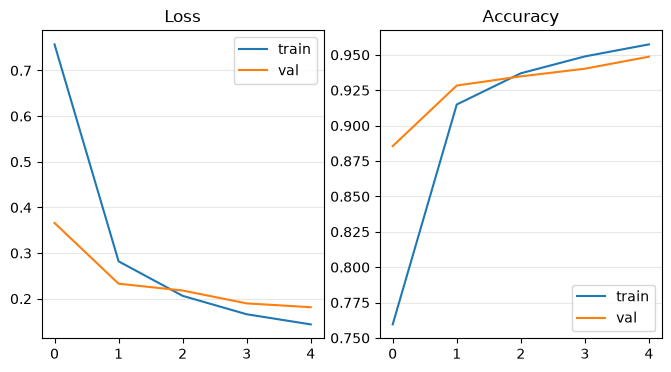

In [47]:
seed = 1961

t_img, test_img, t_target, test_target = train_test_split(
    imgs, targets, test_size=0.5, random_state=seed, stratify=np.argmax(targets, axis=1)
)
train_img, val_img, train_target, val_target = train_test_split(
    t_img, t_target, test_size=0.1, random_state=seed, stratify=np.argmax(t_target, axis=1)
)

train_data = {
    'train': (train_img, train_target),
    'val': (val_img, val_target),
}

loss_model = CrossEntropyLoss()

opt = AdamW()

params = train(
    train_data,
    opt,
    loss_model,
    n_input = 1568,
    n_hidden = 64,
    n_output = 10,
    mode = "kaiming_uniform",
    batch_size = 64,
    epochs = 5,
    shuffle = True,
    norm = True,
    seed = seed
)

# Самостоятельно на Pytorch

In [52]:
import torch
import torchvision

from torch.utils.data import random_split, TensorDataset, DataLoader
from torchvision import datasets
from torchvision.transforms import ToTensor, Normalize

In [53]:
dataset = datasets.MNIST(
        root="./data",
        train=True,
        download=True,
        transform=ToTensor()
    )

mean = (dataset.data.float()/ 255).mean()
std = (dataset.data.float()/ 255).std()
print(mean, std)

tensor(0.1307) tensor(0.3081)


In [54]:
transform = torchvision.transforms.Compose([
    ToTensor(),
    Normalize((mean,), (std,))
])

In [55]:
def data_load(train: bool=True):
    dataset = datasets.MNIST(
        root="./data",
        train=train,
        download=True,
        transform=transform
    )

    return dataset

train_dataset = data_load(True)
t_v_dataset = data_load(False)

In [56]:
val_size = int(0.5 * len(t_v_dataset))
test_size = len(t_v_dataset) - val_size

val_dataset, test_dataset = random_split(t_v_dataset, [val_size, test_size])

In [74]:
class Model(torch.nn.Module):
    def __init__(self, input_channels, height, weight, n_output, h_chan_1=8, h_chan_2=16, kernel_size=3, linear_hidden=128):
        super().__init__()
        first_out = ((height - kernel_size + 1)//2, (weight - kernel_size + 1)//2)
        second_out = ((first_out[0] - kernel_size + 1)//2, (first_out[1] - kernel_size + 1)//2)
        self.first_linear_input = h_chan_2 * second_out[0] * second_out[1]

        self.layers = torch.nn.Sequential(
                        torch.nn.Conv2d(input_channels, h_chan_1, kernel_size),
                        torch.nn.ReLU(),
                        torch.nn.MaxPool2d(2), # 13X13
                        torch.nn.Conv2d(h_chan_1, h_chan_2, kernel_size),
                        torch.nn.ReLU(),
                        torch.nn.MaxPool2d(2), # 5X5
                        torch.nn.Flatten(),
                        torch.nn.Linear(self.first_linear_input, linear_hidden),
                        torch.nn.Dropout(),
                        torch.nn.ReLU(),
                        torch.nn.Linear(linear_hidden, n_output))

    def forward(self, x):
        return self.layers(x)

In [75]:
model = Model(input_channels=1, height=28, weight=28, n_output=10, h_chan_1=8, h_chan_2=16, linear_hidden=128)
batch_size = 128
EPOCHS = 20

In [76]:
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

criterion = torch.nn.CrossEntropyLoss()
optim = torch.optim.AdamW(model.parameters(), lr=1e-3)

Training Model:   0%|          | 0/20 [00:00<?, ?it/s]

Epoch 1/20 on Training:   0%|          | 0/469 [00:00<?, ?it/s]

Epoch 1/20 on Validation:   0%|          | 0/40 [00:00<?, ?it/s]

Epoch 2/20 on Training:   0%|          | 0/469 [00:00<?, ?it/s]

Epoch 2/20 on Validation:   0%|          | 0/40 [00:00<?, ?it/s]

...

Epoch 18/20 on Validation:   0%|          | 0/40 [00:00<?, ?it/s]

Epoch 19/20 on Training:   0%|          | 0/469 [00:00<?, ?it/s]

Epoch 19/20 on Validation:   0%|          | 0/40 [00:00<?, ?it/s]

Epoch 20/20 on Training:   0%|          | 0/469 [00:00<?, ?it/s]

Epoch 20/20 on Validation:   0%|          | 0/40 [00:00<?, ?it/s]

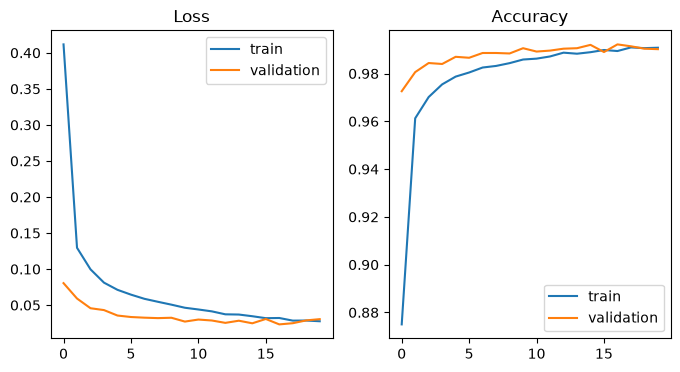

In [77]:
loop = tqdm(range(EPOCHS), desc="Training Model")
train_acc_history = []
train_loss_history = []
val_acc_history = []
val_loss_history = []

for epoch in loop:
    
    total = 0
    correct = 0
    losses = []
    model.train()

    loop_train = tqdm(enumerate(train_loader), leave=False, desc=f"Epoch {epoch+1}/{EPOCHS} on Training", total=len(train_loader))
    for i, (images, targets) in loop_train:
        optim.zero_grad()
        logits = model(images)
        loss = criterion(logits, targets)

        losses.append(loss.item())

        temp_total = len(targets)
        total += temp_total
        temp_correct = torch.sum(torch.argmax(logits, axis=1) == targets).item()
        correct += temp_correct

        loss.backward()
        optim.step()

        if i % 10 == 0:
            loop_train.set_postfix(loss=loss.item(), accuracy=temp_correct/temp_total)

    train_acc_history.append(correct/total)
    train_loss_history.append(np.mean(losses))
    loop.set_postfix(mean_train_loss=train_loss_history[-1])

    total = 0
    correct = 0
    losses = []
    model.eval()

    loop_val = tqdm(enumerate(val_loader), leave=False, desc=f"Epoch {epoch+1}/{EPOCHS} on Validation", total=len(val_loader))
    for i, (images, targets) in loop_val:
        with torch.no_grad():
            logits = model(images)
            loss = criterion(logits, targets)

            losses.append(loss.item())

            temp_total = len(targets)
            total += temp_total
            temp_correct = torch.sum(torch.argmax(logits, axis=1) == targets).item()
            correct += temp_correct

            if i % 10 == 0:
                loop_val.set_postfix(loss=loss.item(), accuracy=temp_correct/temp_total)

    val_acc_history.append(correct/total)
    val_loss_history.append(np.mean(losses))
    loop.set_postfix(mean_val_loss=val_loss_history[-1])


fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(8, 4))

ax1.plot(train_loss_history, label="train")
ax1.plot(val_loss_history, label="validation")
ax1.set_title("Loss")
ax1.legend()

ax2.plot(train_acc_history, label="train")
ax2.plot(val_acc_history, label="validation")
ax2.set_title("Accuracy")
ax2.legend()



In [78]:
total = 0
correct = 0
losses = []

with torch.no_grad():
    for images, targets in test_loader:
        logits = model(images)
        loss = criterion(logits, targets)
        
        losses.append(loss.item())
        total += len(targets)
        correct += torch.sum(torch.argmax(logits, axis=1) == targets).item()

print(f"Test loss: {np.mean(losses):.4f}; Test Accuracy: {correct/total:.4f}")

Test loss: 0.0267; Test Accuracy: 0.9922


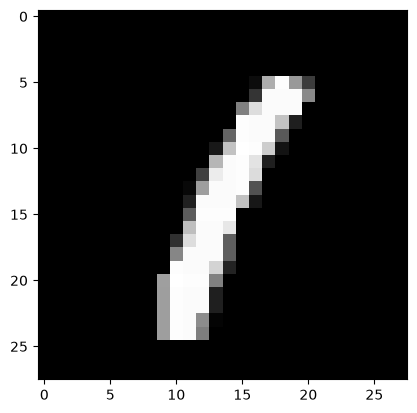

In [92]:
img, target = next(iter(train_loader))
img = img[12].reshape(28, 28)
plt.imshow(img, cmap="grey")